<a href="https://colab.research.google.com/github/Umang-Gisma/M505D/blob/main/M505D_18_FEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports the libraries

In [229]:
import pandas            as pd
import numpy             as np
import seaborn           as sns
import plotly.express    as px
import matplotlib.pyplot as plt

from imblearn.over_sampling    import SMOTE
from sklearn.preprocessing     import StandardScaler
from sklearn.model_selection   import train_test_split
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report

#Connect Data Set

In [230]:
df = pd.read_csv("/content/BreastCancerWisconsinDataSet.csv")
print("Shap of dataset: ", df.shape)

Shap of dataset:  (569, 33)


#Read the data

In [231]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


#Data Exploration

##Data Quality Check

In [232]:
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


##Data Cleaning

In [233]:
df.dropna()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32


In [234]:
df.drop(columns=["id","Unnamed: 32"], axis=1, inplace=True)

In [235]:
df.duplicated().any()

np.False_

In [236]:
df = df.drop_duplicates()

In [237]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


##EDA (Exploratory Data Analysis)

In [238]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


<Axes: xlabel='diagnosis', ylabel='count'>

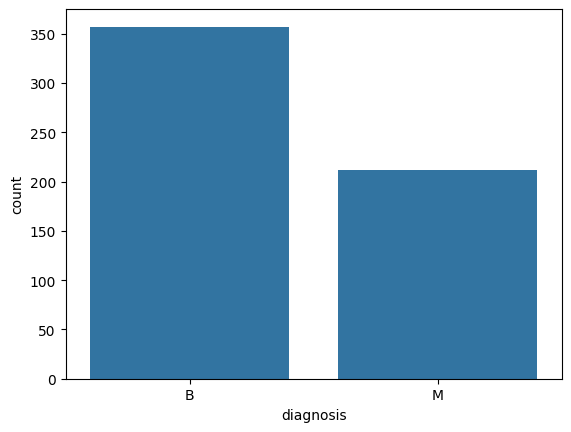

In [239]:
sns.barplot(df["diagnosis"].value_counts())

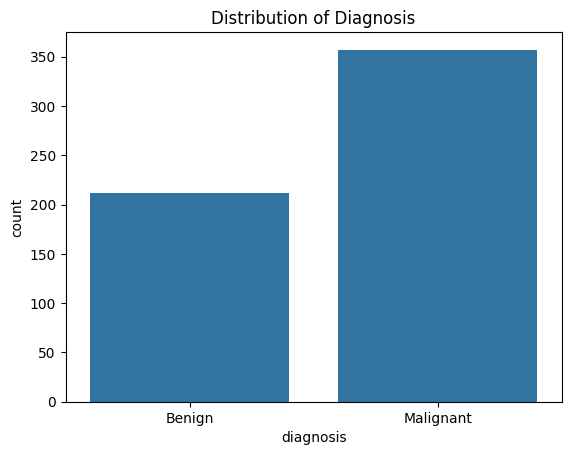

In [240]:
sns.countplot(x='diagnosis', data=df)
plt.xticks([0,1],['Benign','Malignant'])
plt.title("Distribution of Diagnosis")
plt.show()

In [241]:
fig = px.pie(df, names="diagnosis", title="Diagnosis Distribution")
fig.show()

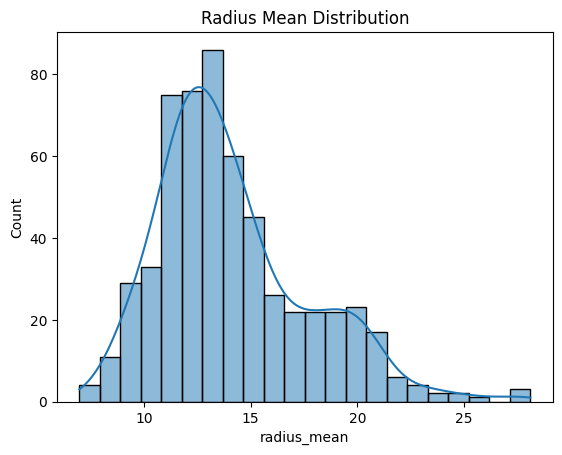

In [242]:
sns.histplot(df['radius_mean'],kde=True)
plt.title("Radius Mean Distribution")
plt.show()

<Axes: >

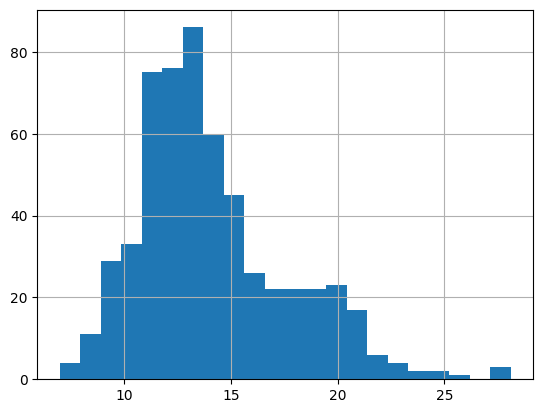

In [243]:
df["radius_mean"].hist(bins="auto")

In [244]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

<Axes: >

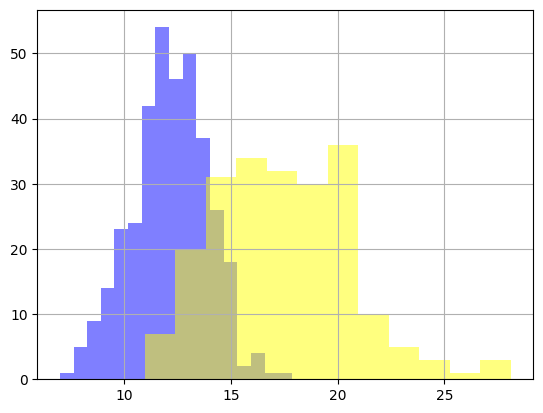

In [245]:
df[df["diagnosis"] == "B"]["radius_mean"].hist(bins="auto", color="blue"  , alpha=0.5)
df[df["diagnosis"] == "M"]["radius_mean"].hist(bins="auto", color="yellow", alpha=0.5)

In [246]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

array([<Axes: title={'center': 'radius_mean'}>,
       <Axes: title={'center': 'texture_mean'}>,
       <Axes: title={'center': 'perimeter_mean'}>], dtype=object)

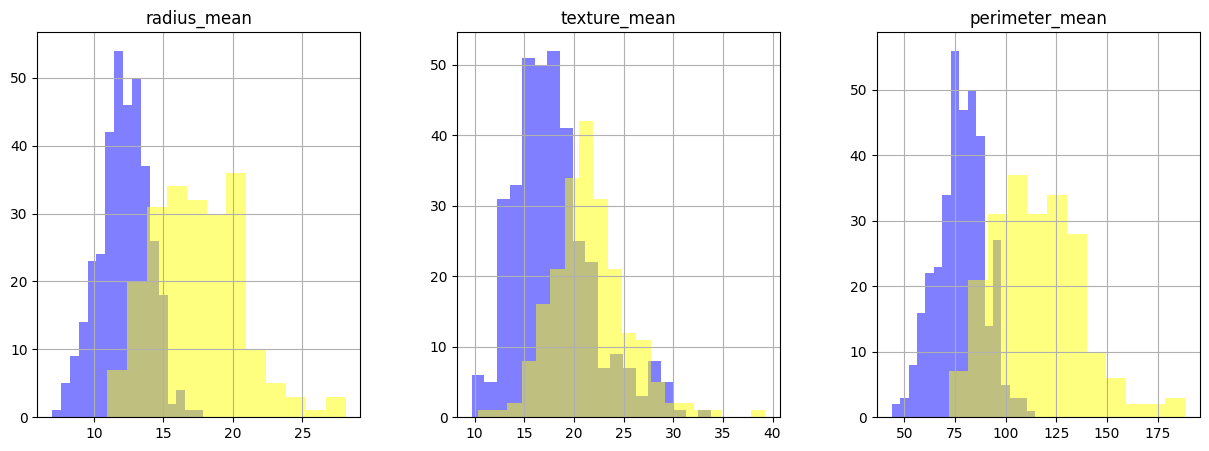

In [247]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
df[df["diagnosis"] == "B"][['radius_mean', 'texture_mean', 'perimeter_mean']].hist(bins="auto", color="blue"  , alpha=.5, ax=ax)
df[df["diagnosis"] == "M"][['radius_mean', 'texture_mean', 'perimeter_mean']].hist(bins="auto", color="yellow", alpha=.5, ax=ax)

In [248]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

array([<Axes: title={'center': 'smoothness_mean'}>,
       <Axes: title={'center': 'area_mean'}>,
       <Axes: title={'center': 'compactness_mean'}>], dtype=object)

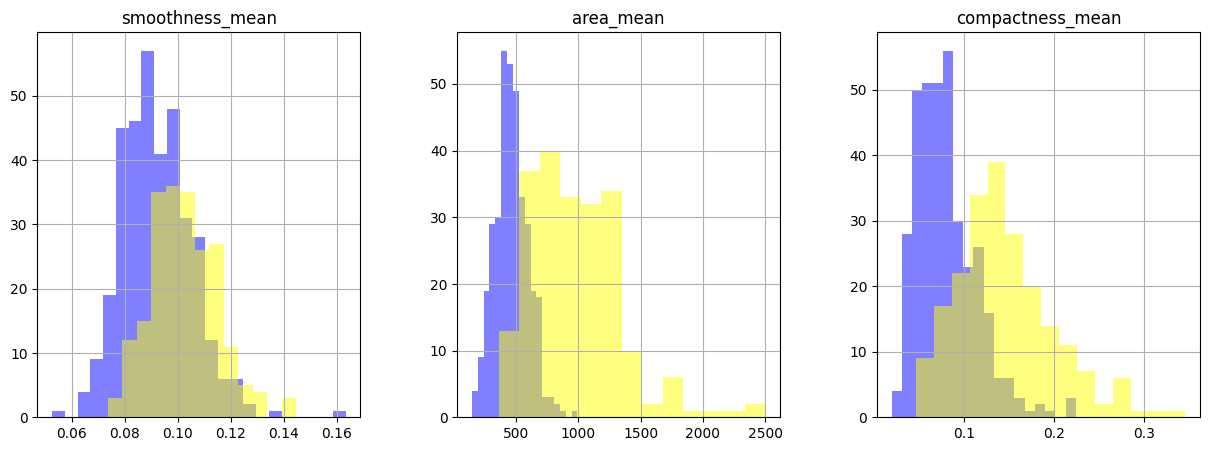

In [249]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
df[df["diagnosis"] == "B"][['smoothness_mean', 'area_mean', 'compactness_mean']].hist(bins="auto", color="blue"  , alpha=.5, ax=ax)
df[df["diagnosis"] == "M"][['smoothness_mean', 'area_mean', 'compactness_mean']].hist(bins="auto", color="yellow", alpha=.5, ax=ax)

In [250]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

array([<Axes: title={'center': 'concavity_mean'}>,
       <Axes: title={'center': 'symmetry_mean'}>,
       <Axes: title={'center': 'fractal_dimension_mean'}>], dtype=object)

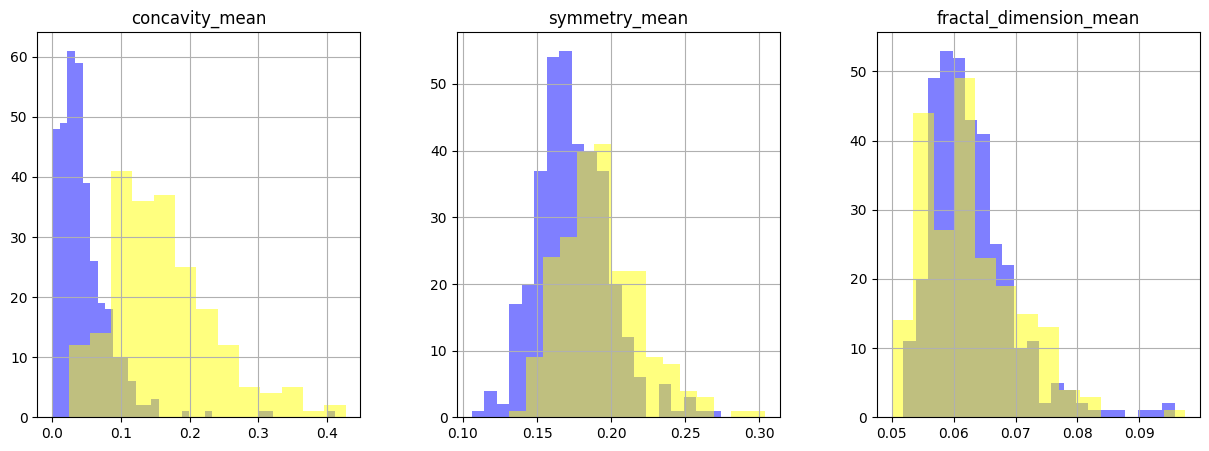

In [251]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
df[df["diagnosis"] == "B"][['concavity_mean', 'symmetry_mean', 'fractal_dimension_mean',]].hist(bins="auto", color="blue"  , alpha=.5, ax=ax)
df[df["diagnosis"] == "M"][['concavity_mean', 'symmetry_mean', 'fractal_dimension_mean']].hist(bins="auto", color="yellow", alpha=.5, ax=ax)

array([[<Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>],
       [<Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>],
       [<Axes: title={'center': 'smoothness_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'compactness_mean'}>]], dtype=object)

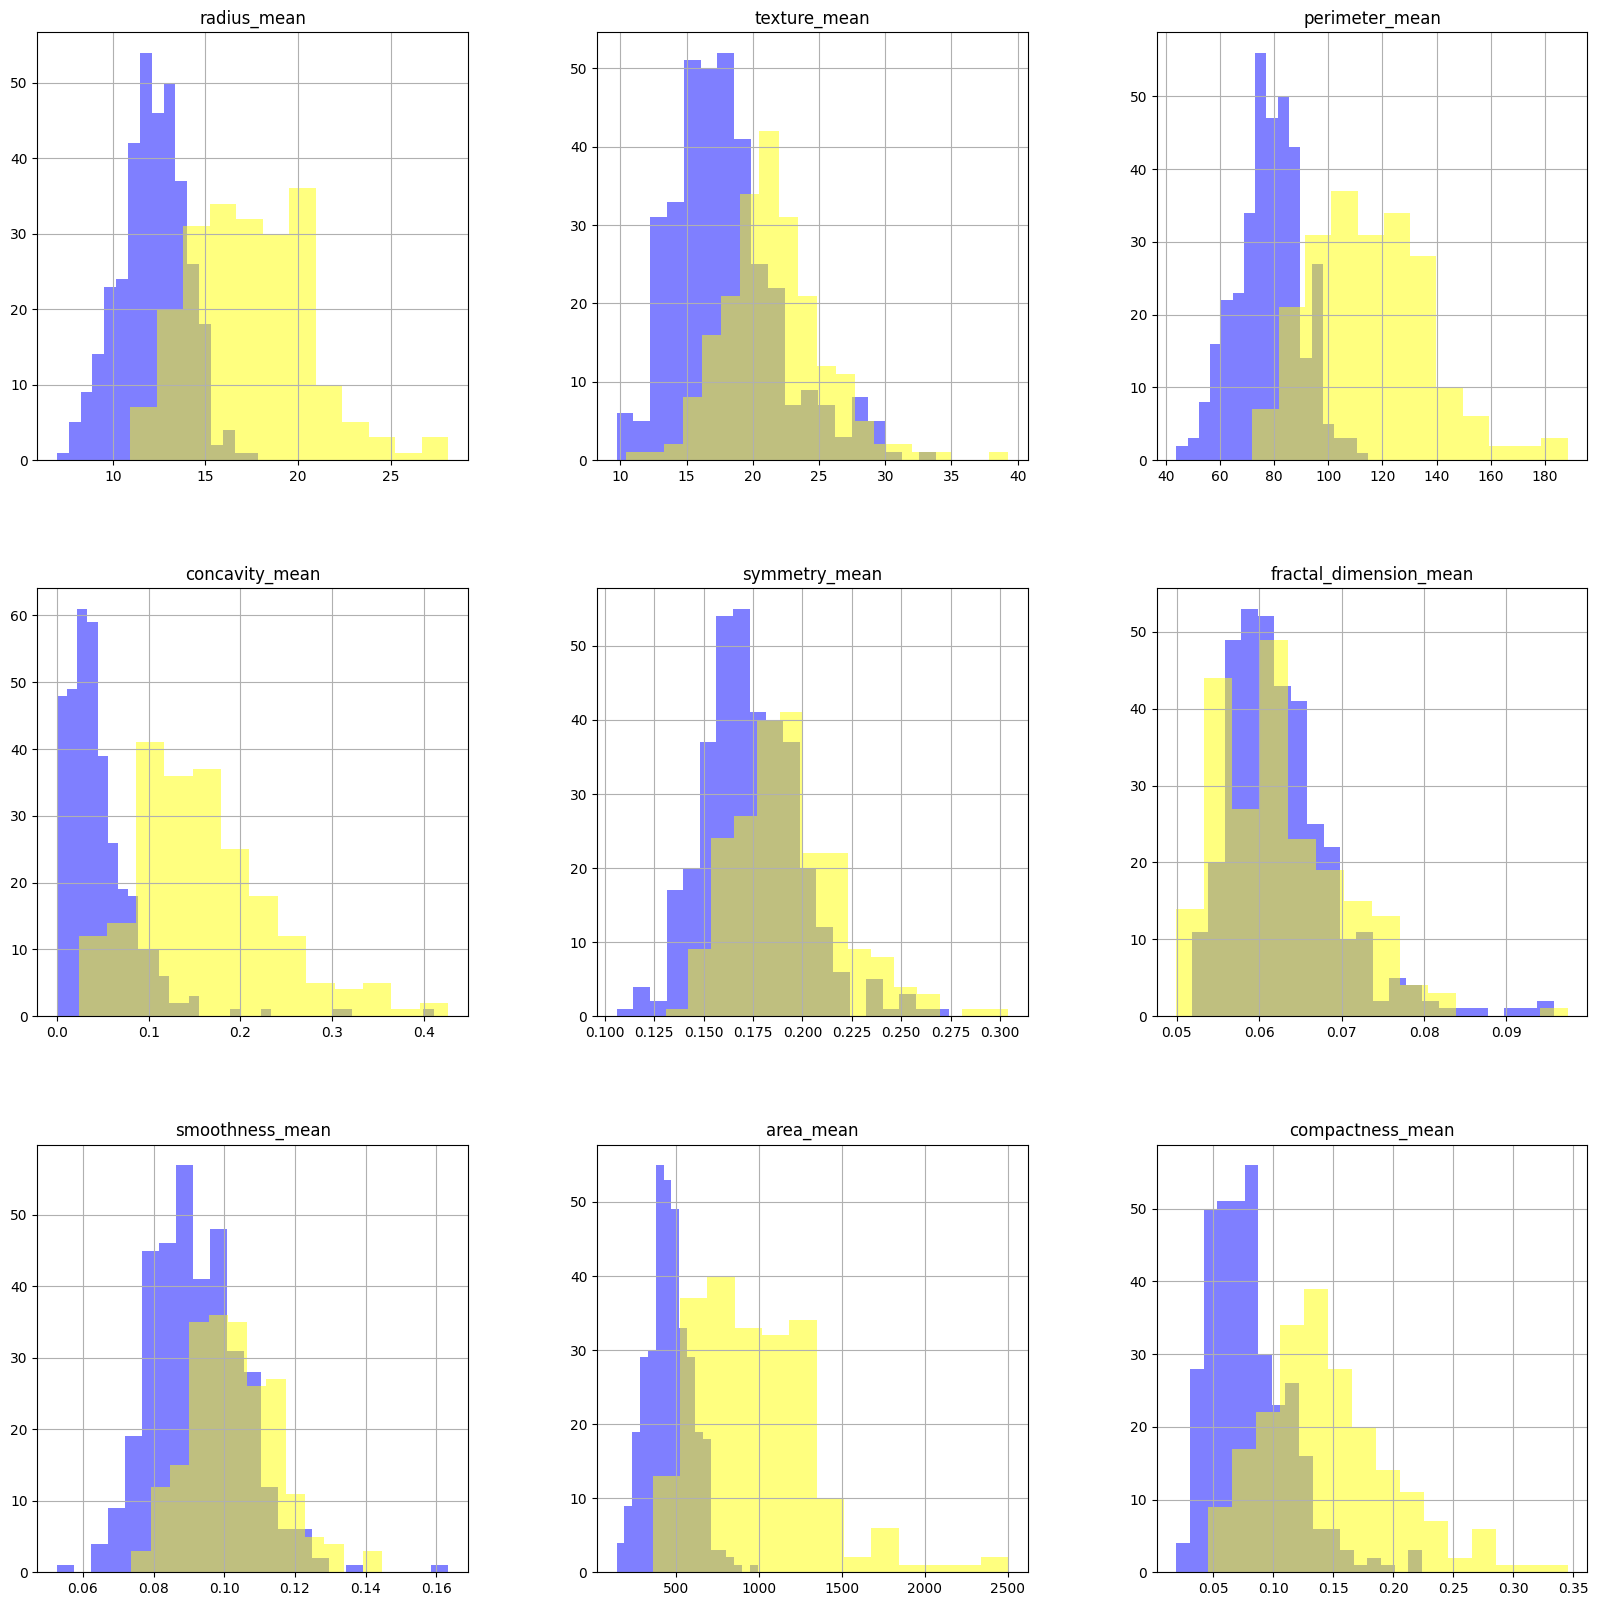

In [252]:
fig, ax = plt.subplots(3, 3, figsize=(20, 20))
df[df["diagnosis"] == "B"][['radius_mean', 'texture_mean', 'perimeter_mean','concavity_mean', 'symmetry_mean', 'fractal_dimension_mean','smoothness_mean', 'area_mean', 'compactness_mean']].hist(bins="auto", color="blue"  , alpha=.5, ax=ax)
df[df["diagnosis"] == "M"][['radius_mean', 'texture_mean', 'perimeter_mean','concavity_mean', 'symmetry_mean', 'fractal_dimension_mean','smoothness_mean', 'area_mean', 'compactness_mean']].hist(bins="auto", color="yellow", alpha=.5, ax=ax)

##Feature Engineering

In [253]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

##Correlation Analysis

In [254]:
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


##Model

In [255]:
y = df['diagnosis'].to_numpy()
y_org = y.astype(float)

df.drop('diagnosis', inplace=True, axis=1)

X = df.values
X_org = X.astype(float)
print(X_org.shape)
print(y_org.shape)

(569, 30)
(569,)


In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train", X_train.shape)
print("X_test" , X_test.shape)

X_train (455, 30)
X_test (114, 30)


###LogisticRegression

In [257]:
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(random_state=42)

In [258]:
y_pred = lr_clf.predict(X_test)

In [259]:
res_df = pd.DataFrame()
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [260]:
confusion_matrix(y_test, y_pred)

array([[70,  1],
       [ 4, 39]])

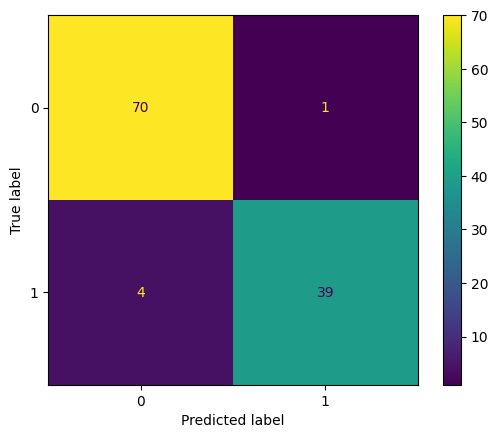

In [261]:
_ = ConfusionMatrixDisplay.from_estimator(lr_clf, X_test, y_test)

In [262]:
accuracy_score(y_test, y_pred)

0.956140350877193

In [263]:
precision_score(y_test, y_pred)

0.975

In [264]:
recall_score(y_test, y_pred)

0.9069767441860465

In [265]:
f1_score(y_test, y_pred)

0.9397590361445783